In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
print(os.getpid())
%cd ../../

import pylib.mix as mix
import cvxpy as cp
import pylib.qucf_read as qucf_r
import pylib.measurement as mse

reload = mix.reload_module

from matplotlib import colors
colors_ = ["blue", "red", "green", "gray", "black"]

plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

12199
/media/work/docs/codes/QuCF/scripts-py


In [2]:
path_qucf_ = "../QuCF/simulations/NN/test/"
path_save_ = "./jupyter-notebooks/NN/results/"
for i in range(100):
    plt.close()

In [8]:
# -----------------------------------------------------
# --- Parameters for sin ---
# -----------------------------------------------------
nx = 4
Nx = 1 << nx

xmax = np.pi/2.
dx = 2. * xmax / (Nx - 1)

alpha_0 = - xmax
alpha_1 = Nx * dx / 2.

# --- reference data ---
x = np.zeros(Nx)
for ii in range(Nx):
    x[ii] = - xmax + dx * ii
y_ref = np.sin(x)

print("\tnx   {:d}".format(nx))
print("\talpha_0   {:0.3e}".format(alpha_0))
print("\talpha_1   {:0.3e}".format(alpha_1))

	nx   4
	alpha_0   -1.571e+00
	alpha_1   1.676e+00


Reading the file ../QuCF/simulations/NN/test//test_OUTPUT.hdf5...
Probabilities have been saved in these QuCF simulations.
Name of the simulation is test
Simulation has been performed  01-16-2025 18:54:48


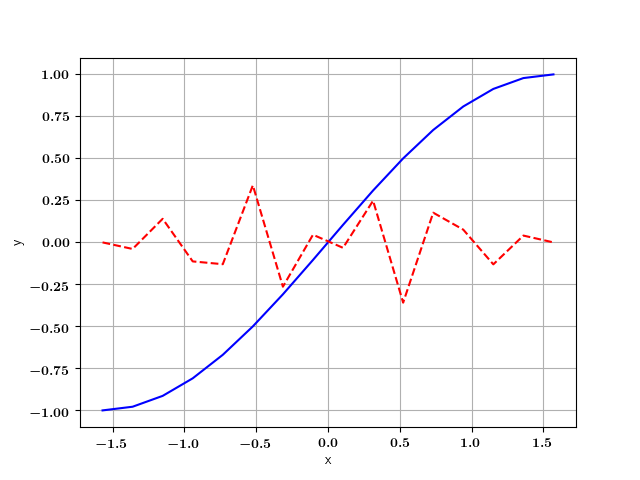

In [71]:
# -----------------------------------------------------
# --- Reading QuCF data ---
# -----------------------------------------------------
om        = mse.MeasOracle__(True)
om.path_  = path_qucf_
om.pname_ = "test"
om.open()

om.set_work_states(0)
y_qc = om.get_var_x({"as": 0, "af": 0}, "rx")
y_qc *= 2**(nx/2.)

# --- Plotting ---
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x, y_ref, "-b")
ax.plot(x, y_qc, "--r")
plt.xlabel('x')
plt.ylabel("y")
plt.grid(True)
plt.show() 

In [ ]:
# ------------------------------------------------------------
# ------------------------------------------------------------
reload(mix)


nx = 2

dd_loc = qucf_r.read_matrix_sparse(path_qucf_, "test_OUTPUT.hdf5") 
dd_loc["A"].plot_structure("Uk: n={:d}".format(nx))

U = np.transpose(dd_loc["A"].dense())
mix.print_matrix(U)

In [12]:

theta_x = np.pi/4.
print(np.cos(theta_x/2.))
print(np.sin(theta_x/2.))
print(theta_x)

0.9238795325112866
0.3826834323650898
0.7853981633974483


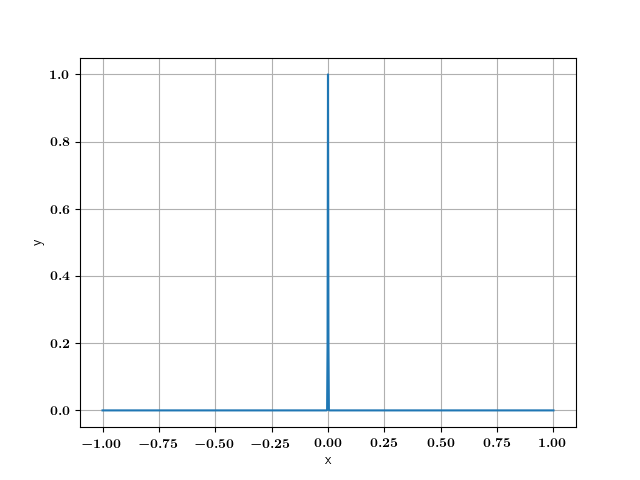

In [32]:
x = np.linspace(-1, 1, 1001)

y1 = np.cos(x*np.pi/2.)
y2 = np.cos(x*np.pi)
y3 = np.cos(x*2.*np.pi)
y = y1 * y2 * y3

y = np.cos(x*np.pi/2.)
for i in range(2, 100):
    y *= np.cos(x*np.pi/2.*i)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x, y)
plt.xlabel('x')
plt.ylabel("y")
plt.grid(True)
plt.show() 